In [1]:
print("Setup: imports and load empirical landscapes")

import sys
from pathlib import Path
sys.path.insert(0, str(Path('..').resolve()))
import style_config as sc

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import logomaker
import mavenn

OUT_DIR = "."

# Load lac promoter additive model (L=75, C=4)
lac_model = mavenn.load_example_model('sortseq_mpa_additive')
lac_theta_dict = lac_model.get_theta(gauge='consensus')
lac_theta = lac_theta_dict['theta_lc']
lac_alphabet = list(lac_model.alphabet)
L_lac, C_lac = lac_theta.shape
print(f"lac promoter: L={L_lac}, C={C_lac}")

# Load GB1 protein additive model (L=55, C=20)
gb1_model = mavenn.load_example_model('gb1_ge_additive')
gb1_theta_dict = gb1_model.get_theta(gauge='consensus')
gb1_theta = gb1_theta_dict['theta_lc']
gb1_alphabet = list(gb1_model.alphabet)
L_gb1, C_gb1 = gb1_theta.shape
print(f"GB1 protein: L={L_gb1}, C={C_gb1}")

Setup: imports and load empirical landscapes


Loading model /Users/jkinney/github/26_stubby/.venv/lib/python3.12/site-packages/mavenn/examples/models/sortseq_mpa_additive ...
Model loaded from these files:
	/Users/jkinney/github/26_stubby/.venv/lib/python3.12/site-packages/mavenn/examples/models/sortseq_mpa_additive.pickle
	/Users/jkinney/github/26_stubby/.venv/lib/python3.12/site-packages/mavenn/examples/models/sortseq_mpa_additive.weights.h5
lac promoter: L=75, C=4
Loading model /Users/jkinney/github/26_stubby/.venv/lib/python3.12/site-packages/mavenn/examples/models/gb1_ge_additive ...
Model loaded from these files:
	/Users/jkinney/github/26_stubby/.venv/lib/python3.12/site-packages/mavenn/examples/models/gb1_ge_additive.pickle
	/Users/jkinney/github/26_stubby/.venv/lib/python3.12/site-packages/mavenn/examples/models/gb1_ge_additive.weights.h5
GB1 protein: L=55, C=20


Figure 1: empirical landscapes


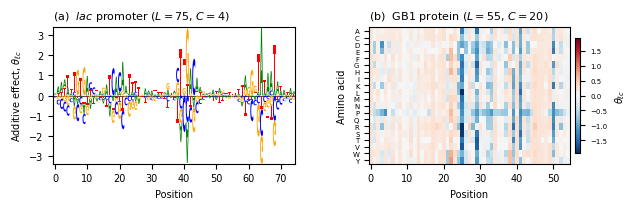

Saved fig1.pdf and fig1.png


In [2]:
print("Figure 1: empirical landscapes")

fig, axes = plt.subplots(1, 2, figsize=(sc.TEXT_WIDTH, 2.2))

# --- Panel (a): lac promoter sequence logo ---
ax = axes[0]
logo_df = pd.DataFrame(lac_theta, columns=lac_alphabet)
logomaker.Logo(logo_df, ax=ax, color_scheme='classic', center_values=True)
ax.set_xlabel('Position')
ax.set_ylabel(r'Additive effect, $\theta_{\ell c}$')
ax.set_title(r'(a)  $\it{lac}$ promoter ($L=75$, $C=4$)',
             fontsize=sc.PANEL_TITLE_SIZE, loc='left')

# --- Panel (b): GB1 protein heatmap ---
ax = axes[1]
im = ax.imshow(gb1_theta.T, aspect='auto', cmap='RdBu_r',
               vmin=-np.abs(gb1_theta).max(),
               vmax=np.abs(gb1_theta).max(),
               interpolation='nearest')

# Label amino acid alphabet on y-axis
ax.set_yticks(range(C_gb1))
ax.set_yticklabels(gb1_alphabet, fontsize=5)
ax.set_xlabel('Position')
ax.set_ylabel('Amino acid')
ax.set_title(r'(b)  GB1 protein ($L=55$, $C=20$)',
             fontsize=sc.PANEL_TITLE_SIZE, loc='left')

# Colorbar
cbar = fig.colorbar(im, ax=ax, **sc.COLORBAR_KW)
cbar.set_label(r'$\theta_{\ell c}$')
cbar.ax.tick_params(labelsize=5)

fig.tight_layout(w_pad=3)
fig.savefig(f"{OUT_DIR}/fig1.pdf", bbox_inches='tight')
fig.savefig(f"{OUT_DIR}/fig1.png", dpi=300, bbox_inches='tight')
plt.show()
print("Saved fig1.pdf and fig1.png")